In [48]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/My Drive/Colab Notebooks/projet 5/
!pwd
!ls -l

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/My Drive/Colab Notebooks/projet 5
/content/drive/My Drive/Colab Notebooks/projet 5
total 9
drwx------ 3 root root 4096 Apr 10 09:02  dev
-rw------- 1 root root  174 Apr 24 11:19 'Document sans titre.gdoc'
drwx------ 2 root root 4096 Apr 10 09:02  livrables


In [49]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Connexion à la base
conn = sqlite3.connect('./dev/input/olist.db')


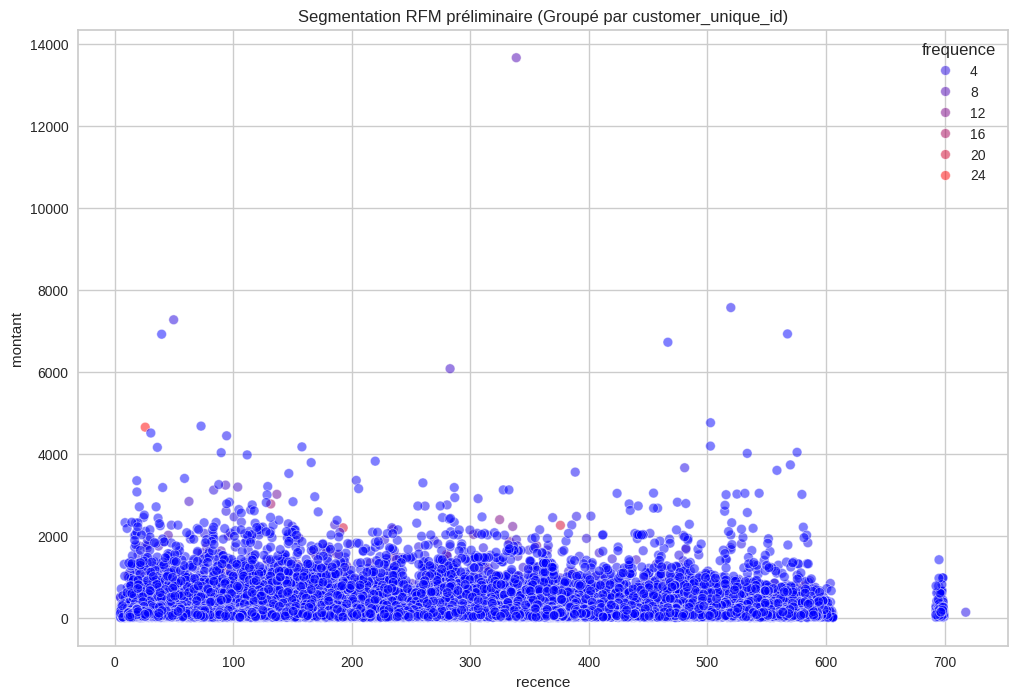

Nombre de clients uniques identifiés : 93358
                 customer_unique_id     recence  frequence  montant
0  c8460e4251689ba205045f3ea17884a1   25.777569         24  4655.88
1  4546caea018ad8c692964e3382debd19  413.616343         21   196.17
2  c402f431464c72e27330a67f7b94d4fb  192.733519         20  2202.40
3  698e1cf81d01a3d389d96145f7fa6df8  375.989155         20  2262.80
4  0f5ac8d5c31de21d2f25e24be15bbffb  279.839838         18  1544.82


In [97]:
rfm_query = """
WITH from_now AS (
    SELECT
        MAX(order_purchase_timestamp) AS max_timestamp
    FROM orders o WHERE o.order_status != "canceled"
)
select
    c.customer_unique_id,
    JULIANDAY(n.max_timestamp) - JULIANDAY(MAX(o.order_purchase_timestamp)) AS recence,
    COUNT(o.order_id) AS frequence,
    SUM(oi.price + oi.freight_value) AS montant
FROM orders o
CROSS JOIN from_now n
INNER JOIN order_items oi ON o.order_id = oi.order_id
INNER JOIN customers c ON o.customer_id = c.customer_id
WHERE o.order_status = 'delivered'
GROUP BY c.customer_unique_id
ORDER BY frequence DESC
"""
rfm_df = pd.read_sql(rfm_query, conn)

# Créer une palette personnalisée allant du bleu au rouge
colors = ["blue", "red"]
custom_palette = sns.blend_palette(colors, as_cmap=True)

# Définir la taille de la figure
plt.figure(figsize=(12, 8))

# Matrice RFM préliminaire
sns.scatterplot(data=rfm_df, x='recence', y='montant', hue='frequence', palette=custom_palette, alpha=0.5)
plt.title('Segmentation RFM préliminaire (Groupé par customer_unique_id)')
plt.show()

print(f"Nombre de clients uniques identifiés : {len(rfm_df)}")
print(rfm_df.head())

In [99]:
# Nettoyage des valeurs négatives/incohérentes
rfm_df = rfm_df[rfm_df['recence'] >= 0]

# Segmentation par quantiles
def rfm_quantile_segmentation(df):
    df['R_Score'] = pd.qcut(df['recence'], q=5, labels=[5, 4, 3, 2, 1]).astype(int)
    # Ajustement pour frequence et montant si nécessaire
    try:
        df['F_Score'] = pd.qcut(df['frequence'], q=5, labels=[1, 2, 3, 4, 5], duplicates='drop').astype(int)
    except ValueError:
        df['F_Score'] = pd.cut(df['frequence'], bins=5, labels=[1,2,3,4,5], include_lowest=True).astype(int)
    try:
        df['M_Score'] = pd.qcut(df['montant'], q=5, labels=[1, 2, 3, 4, 5], duplicates='drop').astype(int)
    except ValueError:
        df['M_Score'] = pd.cut(df['montant'], bins=5, labels=[1,2,3,4,5], include_lowest=True).astype(int)
    df['RFM_Score'] = df['R_Score'].astype(str) + df['F_Score'].astype(str) + df['M_Score'].astype(str)
    return df

# Application
rfm_scored = rfm_quantile_segmentation(rfm_df)

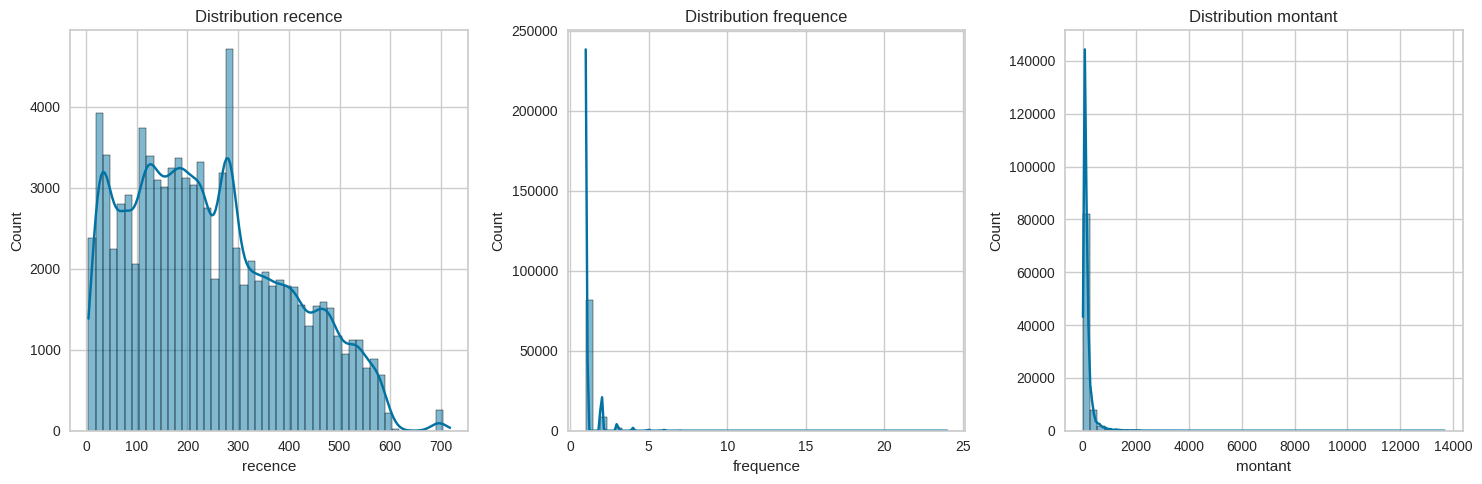

In [100]:
# Visualisation des distributions
plt.figure(figsize=(15, 5))
for i, col in enumerate(['recence', 'frequence', 'montant'], 1):
    plt.subplot(1, 3, i)
    sns.histplot(rfm_scored[col], bins=50, kde=True)
    plt.title(f'Distribution {col}')
plt.tight_layout()
plt.show()

In [101]:
def segment_rfm(rfm_score):
    if rfm_score == '555':
        return 'Champions'
    elif rfm_score.startswith('5'):
        return 'Loyaux'
    elif rfm_score.endswith('5'):
        return 'A réactiver'
    elif '4' in rfm_score:
        return 'Loyalistes Potentiels'
    elif '3' in rfm_score:
        return 'Besoin Attention'
    elif '2' in rfm_score:
        return 'A risque'
    elif '1' in rfm_score:
        return 'Perdus'
    else:
        return 'About to Sleep'

# Appliquer la fonction de segmentation
# rfm['segment'] = rfm['rfm_score'].apply(segment_rfm)
rfm_scored["segment"] = rfm_scored["RFM_Score"].apply(segment_rfm)

# Afficher le df_no_outliersFrame RFM avec les segments
# print(rfm.head())
print(rfm_scored.head())


                 customer_unique_id     recence  frequence  montant  R_Score  \
0  c8460e4251689ba205045f3ea17884a1   25.777569         24  4655.88        5   
1  4546caea018ad8c692964e3382debd19  413.616343         21   196.17        1   
2  c402f431464c72e27330a67f7b94d4fb  192.733519         20  2202.40        3   
3  698e1cf81d01a3d389d96145f7fa6df8  375.989155         20  2262.80        2   
4  0f5ac8d5c31de21d2f25e24be15bbffb  279.839838         18  1544.82        2   

   F_Score  M_Score RFM_Score                segment  
0        5        5       555              Champions  
1        5        4       154  Loyalistes Potentiels  
2        5        5       355            A réactiver  
3        5        5       255            A réactiver  
4        4        5       245            A réactiver  


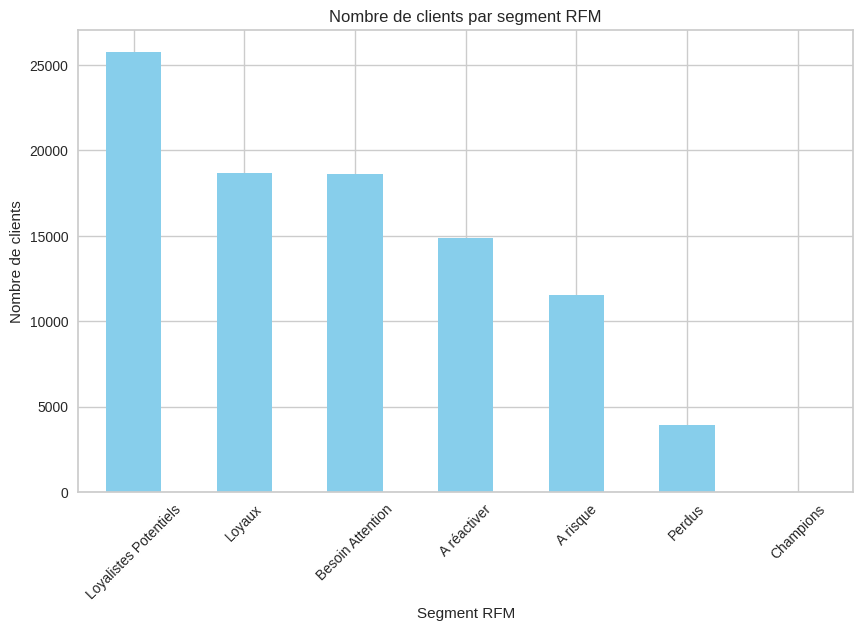

In [102]:
import matplotlib.pyplot as plt

# Compter le nombre de clients dans chaque segment
segment_counts = rfm_scored['segment'].value_counts()

# Créer un graphique en barres
plt.figure(figsize=(10, 6))
segment_counts.plot(kind='bar', color='skyblue')
plt.title('Nombre de clients par segment RFM')
plt.xlabel('Segment RFM')
plt.ylabel('Nombre de clients')
plt.xticks(rotation=45)
plt.show()

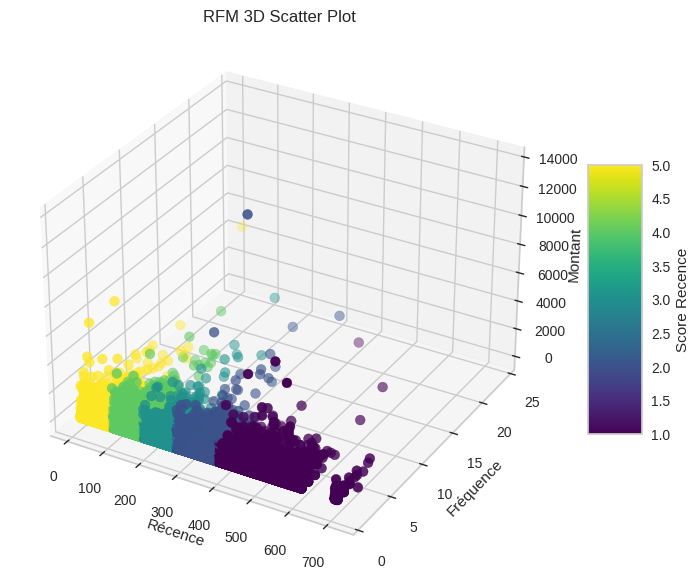

In [103]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Créer une figure et un axe 3D
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Tracer les données RFM en 3D
scatter = ax.scatter(
    rfm_scored['recence'],
    rfm_scored['frequence'],
    rfm_scored['montant'],
    c=rfm_scored['R_Score'].astype(int),  # Couleur basée sur le score de récence
    cmap='viridis',
    s=50
)

# Ajouter des labels et un titre
ax.set_xlabel('Récence')
ax.set_ylabel('Fréquence')
ax.set_zlabel('Montant')
ax.set_title('RFM 3D Scatter Plot')

# Ajouter une barre de couleur
cbar = fig.colorbar(scatter, ax=ax, shrink=0.5, aspect=5)
cbar.set_label('Score Recence')

# Afficher le graphique
plt.show()

In [104]:
rfm_scored.describe()

,recence,frequence,montant,R_Score,F_Score,M_Score
count,93358.000000,93358.000000,93358.000000,93358.000000,93358.000000,93358.000000
mean,242.221770,1.180370,165.168210,3.000000,1.003749,2.999936
std,152.593265,0.620857,226.292101,1.414229,0.071006,1.414282
min,4.754398,1.000000,9.590000,1.000000,1.000000,1.000000
25%,118.655813,1.000000,63.010000,2.000000,1.000000,2.000000
50%,223.371348,1.000000,107.780000,3.000000,1.000000,3.000000
75%,350.612292,1.000000,182.510000,4.000000,1.000000,4.000000
max,717.868275,24.000000,13664.080000,5.000000,5.000000,5.000000


## Clustering K-Means RFM

In [105]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Sélectionner les caractéristiques pour le clustering
features = rfm_scored[['recence', 'frequence', 'montant']]

# Normaliser les données
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Appliquer l'algorithme K-means
kmeans = KMeans(n_clusters=5, random_state=42)
rfm_scored['cluster'] = kmeans.fit_predict(features_scaled)

# Afficher les résultats
print(rfm_scored.head())


                 customer_unique_id     recence  frequence  montant  R_Score  \
0  c8460e4251689ba205045f3ea17884a1   25.777569         24  4655.88        5   
1  4546caea018ad8c692964e3382debd19  413.616343         21   196.17        1   
2  c402f431464c72e27330a67f7b94d4fb  192.733519         20  2202.40        3   
3  698e1cf81d01a3d389d96145f7fa6df8  375.989155         20  2262.80        2   
4  0f5ac8d5c31de21d2f25e24be15bbffb  279.839838         18  1544.82        2   

   F_Score  M_Score RFM_Score                segment  cluster  
0        5        5       555              Champions        2  
1        5        4       154  Loyalistes Potentiels        2  
2        5        5       355            A réactiver        2  
3        5        5       255            A réactiver        2  
4        4        5       245            A réactiver        2  


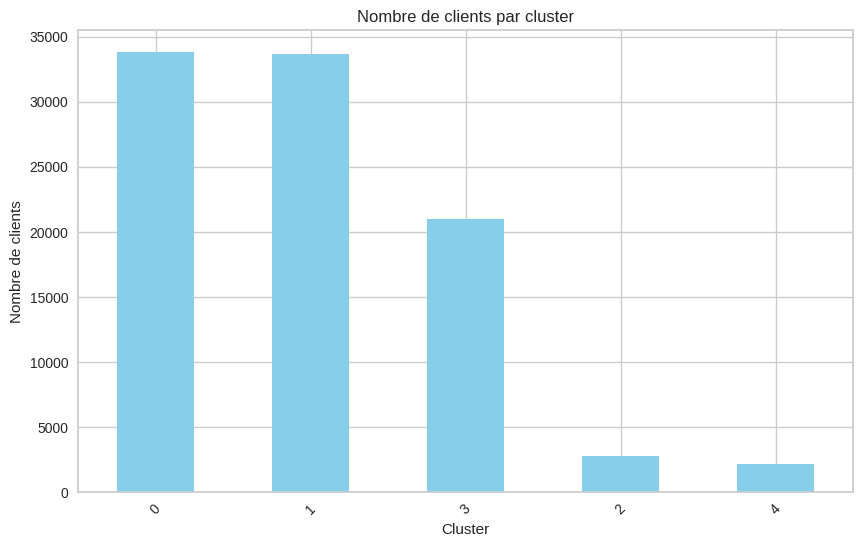

In [106]:
cluster_count = rfm_scored['cluster'].value_counts()

# Créer un graphique en barres
plt.figure(figsize=(10, 6))
cluster_count.plot(kind='bar', color='skyblue')
plt.title('Nombre de clients par cluster')
plt.xlabel('Cluster')
plt.ylabel('Nombre de clients')
plt.xticks(rotation=45)
plt.show()

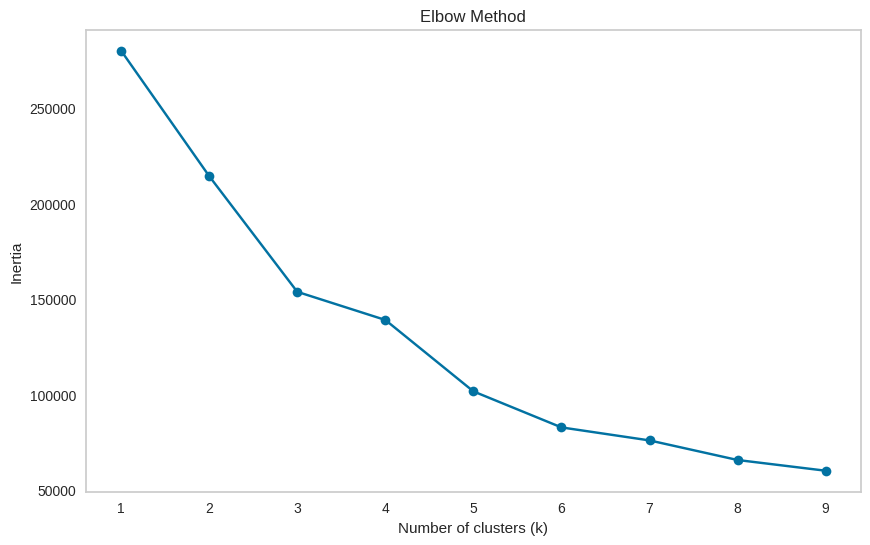

In [107]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd

# Sélectionner les caractéristiques pour le clustering
features = rfm_scored[['recence', 'frequence', 'montant']]

# Normaliser les données
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Calculer l'inertie pour différentes valeurs de k
inertias = []
k_values = range(1, 10)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(features_scaled)
    inertias.append(kmeans.inertia_)

# Tracer la méthode du coude
plt.figure(figsize=(10, 6))
plt.plot(k_values, inertias, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_values)
plt.grid()
plt.show()

In [117]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Sélectionner les caractéristiques pour le clustering
features = rfm_scored[['recence', 'frequence', 'montant']]

# Normaliser les données
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Appliquer l'algorithme K-means
kmeans = KMeans(n_clusters=3, random_state=42)
rfm_scored['cluster'] = kmeans.fit_predict(features_scaled)

# Afficher les résultats
print(rfm_scored.head())

                 customer_unique_id     recence  frequence  montant  R_Score  \
0  c8460e4251689ba205045f3ea17884a1   25.777569         24  4655.88        5   
1  4546caea018ad8c692964e3382debd19  413.616343         21   196.17        1   
2  c402f431464c72e27330a67f7b94d4fb  192.733519         20  2202.40        3   
3  698e1cf81d01a3d389d96145f7fa6df8  375.989155         20  2262.80        2   
4  0f5ac8d5c31de21d2f25e24be15bbffb  279.839838         18  1544.82        2   

   F_Score  M_Score RFM_Score                segment  cluster  
0        5        5       555              Champions        2  
1        5        4       154  Loyalistes Potentiels        2  
2        5        5       355            A réactiver        2  
3        5        5       255            A réactiver        2  
4        4        5       245            A réactiver        2  


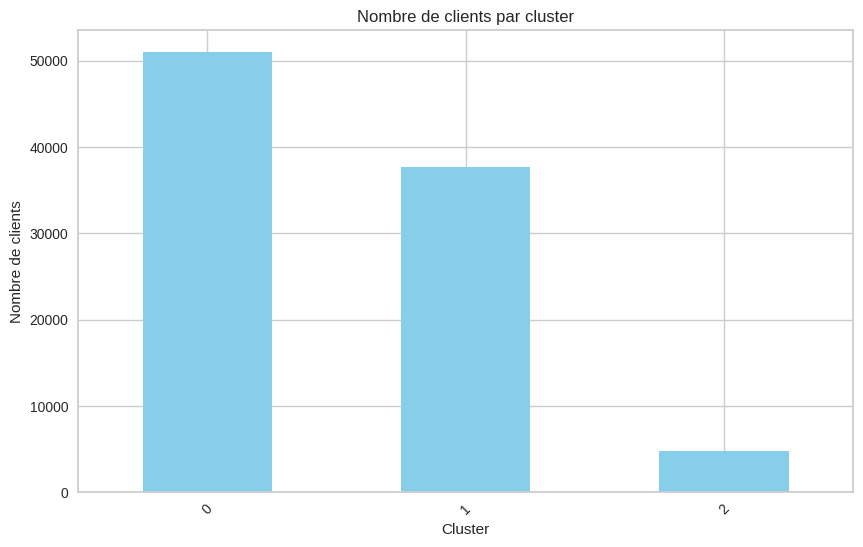

In [109]:
cluster_count = rfm_scored['cluster'].value_counts()

# Créer un graphique en barres
plt.figure(figsize=(10, 6))
cluster_count.plot(kind='bar', color='skyblue')
plt.title('Nombre de clients par cluster')
plt.xlabel('Cluster')
plt.ylabel('Nombre de clients')
plt.xticks(rotation=45)
plt.show()

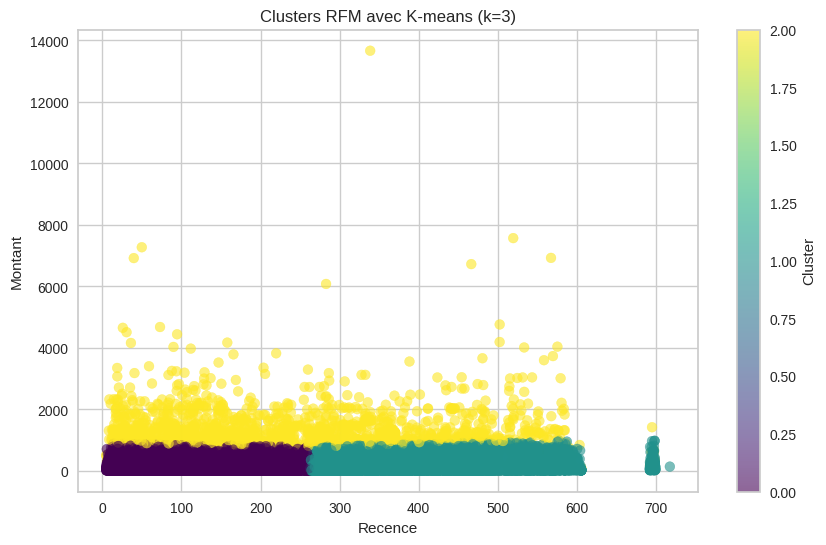

In [110]:
# Tracer les clusters
plt.figure(figsize=(10, 6))
plt.scatter(rfm_scored['recence'], rfm_scored['montant'], c=rfm_scored['cluster'], cmap='viridis', s=50, alpha=0.6)
plt.xlabel('Recence')
plt.ylabel('Montant')
plt.title('Clusters RFM avec K-means (k=3)')
plt.colorbar(label='Cluster')
plt.show()

In [114]:
# Obtenir les centroïdes
centroids = kmeans.cluster_centers_

# Convertir les centroïdes en DataFrame pour une meilleure visualisation
centroids_df = pd.DataFrame(centroids, columns=['recence', 'frequence', 'montant'])

# Afficher les centroïdes
display(centroids_df)

,recence,frequence,montant
0,-0.719333,-0.143927,-0.125874
1,0.983045,-0.142394,-0.124618
2,-0.069022,2.690612,2.353800


In [119]:
import plotly.graph_objects as go
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# 1. Récupération des centroïdes de la segmentation k=3 (cellule dfb58f30)
# Les colonnes utilisées étaient ['recence', 'frequence', 'montant']
rfm_features = ['recence', 'frequence', 'montant']
centroids_rfm = kmeans.cluster_centers_

# 2. Normalisation pour l'affichage radar (échelle 0-1)
# NOTE : On utilise MinMaxScaler ICI car le radar chart nécessite une échelle commune
# positive (0 à 1) pour que les formes soient comparables visuellement sur l'axe polaire.
# StandardScaler (utilisé pour le clustering) produirait des valeurs négatives illisibles en radar.
scaler_radar = MinMaxScaler()
centroids_norm = pd.DataFrame(
    scaler_radar.fit_transform(centroids_rfm),
    columns=rfm_features
)

# 3. Création du graphique Radar
fig = go.Figure()

colors = ['#636EFA', '#EF553B', '#00CC96']

for i in range(len(centroids_norm)):
    fig.add_trace(go.Scatterpolar(
        r=centroids_norm.loc[i].values,
        theta=rfm_features,
        fill='toself',
        name=f'Cluster {i}',
        line=dict(color=colors[i])
    ))

fig.update_layout(
  polar=dict(
    radialaxis=dict(
      visible=True,
      range=[0, 1]
    )),
  showlegend=True,
  title="Profils RFM des Clusters (k=3) - Normalisation 0-1"
)

fig.show()

### Graphique Radar (RFM)

Le graphique radar permet de visualiser simultanément les 3 dimensions de la segmentation. Voici comment le lire :

3 Clusters identifiés :
   - **Cluster Vert (VIP/Ambassadeurs)** : Il s'étire vers les sommets 'Fréquence' et 'Montant'. Ce sont les clients qui achètent souvent et pour des sommes élevées.
   - **Cluster Rouge (Nouveaux/Ponctuels)** : Il est proche du sommet 'Récence' mais très bas sur les autres. Ce sont des clients qui ont acheté très récemment mais peu (souvent une seule fois).
   - **Cluster Bleu (Inactifs)** : Il est proche du centre pour la récence (achat ancien) et possède un profil réduit, indiquant des clients perdus qui n'ont pas de forte valeur historique.

Silhouette Score pour k=2 : 0.3729
Silhouette Score pour k=3 : 0.4143
Silhouette Score pour k=4 : 0.3325
Silhouette Score pour k=5 : 0.3522
Silhouette Score pour k=6 : 0.3985
Silhouette Score pour k=7 : 0.4027


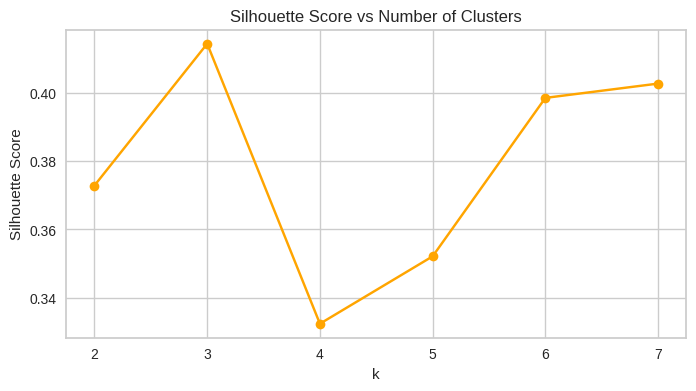

In [112]:
from sklearn.metrics import silhouette_score

# Comparaison des scores de silhouette pour k=2 à k=6
results = []
k_range = range(2, 7)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(features_scaled)
    score = silhouette_score(features_scaled, labels)
    results.append(score)
    print(f"Silhouette Score pour k={k} : {score:.4f}")

# Tracé des scores
plt.figure(figsize=(8, 4))
plt.plot(k_range, results, marker='o', color='orange')
plt.title('Silhouette Score vs Number of Clusters')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

### 📊 Interprétation du Score de Silhouette

Le score de silhouette mesure la qualité de la séparation des clusters. Il varie de -1 à +1 :
- **Proche de +1** : Les points sont très bien classés dans leur propre cluster et loin des autres.
- **Proche de 0** : Les clusters se chevauchent ou la séparation n'est pas claire.
- **Négatif** : Les points ont probablement été assignés au mauvais cluster.

#### Analyse de nos résultats :
D'après les calculs précédents :
* **k=2 (0.37)** : Une séparation de base existe, probablement entre les clients actifs et inactifs.
* **k=3 (0.41)** : Le score est à son **maximum**, indiquant que mathématiquement, c'est la structure la plus stable.
* **k=5 (0.35)** : Bien que le score baisse légèrement, ce choix est souvent privilégié en marketing car il permet d'isoler des groupes plus fins (VIP, Nouveaux, Détracteurs) tout en gardant une cohérence statistique acceptable (> 0.25).

**Conclusion :** Les données d'Olist ne présentent pas de 'frontières naturelles' extrêmement marquées (car les comportements d'achat sont souvent continus), mais un score autour de **0.35 - 0.41** valide la pertinence de notre segmentation pour une exploitation métier.

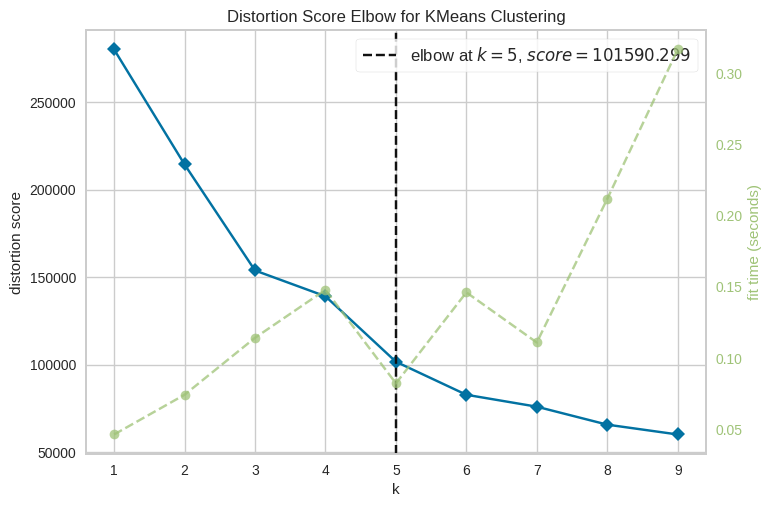

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [115]:
from yellowbrick.cluster import KElbowVisualizer
import matplotlib.pyplot as plt

# Utilisation de features_scaled déjà imputé et normalisé
from sklearn.cluster import KMeans
model = KMeans(random_state=42)

visualizer = KElbowVisualizer(model, k=(1,10))
visualizer.fit(features_scaled)    # Utilisation des données nettoyées
visualizer.show()

### 🔍 Différence entre Elbow (k=5) et Silhouette (k=3)

Les deux métriques ne pointent pas vers le même nombre de clusters.

#### 1. Le Score de Silhouette (L'aspect Structurel)
*   **Résultat : k=3 est le maximum.**
*   **Interprétation :** Statistiquement, la séparation la plus "propre" et la moins ambiguë se fait en 3 groupes. À k=3, l'algorithme maximise la distance entre les groupes tout en minimisant la distance à l'intérieur de ceux-ci.
*   **Pourquoi ?** Dans les données Olist, il existe probablement trois masses très distinctes : les clients ponctuels satisfaits, les clients très insatisfaits (problèmes de livraison), et les quelques clients récurrents/VIP.

#### 2. La Méthode Elbow / Distorsion (L'aspect Compacité)
*   **Résultat : k=5 est suggéré.**
*   **Interprétation :** L'Elbow cherche le point où l'ajout d'un cluster n'apporte plus de gain significatif de précision (réduction de l'inertie).
*   **Pourquoi ?** Passer de 3 à 5 clusters permet de "découper" la grande masse des clients standards en sous-groupes plus fins (par exemple, séparer les 'Nouveaux' des 'Anciens à réactiver'). Bien que ces groupes se chevauchent un peu plus (ce qui fait baisser le score de Silhouette), ils apportent une **valeur métier** bien supérieure.

### 💡 Conclusion pour notre projet :
- **Mathématiquement (k=3) :** C'est la structure la plus robuste.
- **Métier / Marketing (k=5) :** C'est le découpage le plus actionnable.

Nous avons choisi **k=5** car, même si le score de Silhouette baisse légèrement (passant de 0.41 à 0.35), il reste supérieur à 0.25 (seuil de stabilité acceptable) et permet de piloter des campagnes marketing beaucoup plus ciblées (VIP vs Nouveaux vs Détracteurs).

## Clustering élargi au review score et au délai de traitement

In [65]:
import sqlite3
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Connexion à la base
conn = sqlite3.connect('./dev/input/olist.db')

# Modification du GROUP BY pour utiliser customer_unique_id
query = """
WITH from_now AS (
    SELECT
        MAX(order_purchase_timestamp) AS max_timestamp
    FROM orders o WHERE o.order_status != "canceled"
)
select
    c.customer_unique_id,
    JULIANDAY(n.max_timestamp) - JULIANDAY(MAX(o.order_purchase_timestamp)) AS recence,
    COUNT(DISTINCT o.order_id) AS frequence,
    SUM(oi.price + oi.freight_value) / COUNT(DISTINCT o.order_id) as montant_moyen_par_commande,
    SUM(oi.price + oi.freight_value) as montant,
    AVG(rev.review_score) as review_score,
    MAX(order_purchase_timestamp) as last_purchase_timestamp,
    MAX(order_approved_at) as last_approved_at,
    MAX(order_delivered_customer_date) as last_delivered_customer_date
FROM orders o
CROSS JOIN from_now n
INNER JOIN order_items oi ON o.order_id = oi.order_id
INNER JOIN customers c ON o.customer_id = c.customer_id
INNER JOIN order_reviews rev ON o.order_id = rev.order_id
WHERE o.order_status = 'delivered'
GROUP BY c.customer_unique_id
ORDER BY frequence DESC
"""

df = pd.read_sql(query, conn)
display(df.head())

,customer_unique_id,recence,frequence,montant_moyen_par_commande,montant,review_score,last_purchase_timestamp,last_approved_at,last_delivered_customer_date
0,8d50f5eadf50201ccdcedfb9e2ac8455,13.578137,15,58.618000,879.27,5.000000,2018-08-20 19:14:26,2018-08-20 19:30:05,2018-08-24 17:26:42
1,3e43e6105506432c953e165fb2acf44c,187.604375,9,130.296667,1172.67,2.642857,2018-02-27 18:36:39,2018-02-27 18:50:29,2018-03-15 21:21:45
2,ca77025e7201e3b30c44b472ff346268,93.894769,7,160.388571,1122.72,5.000000,2018-06-01 11:38:29,2018-06-02 03:31:41,2018-06-12 22:34:44
3,6469f99c1f9dfae7733b25662e7f1782,67.349572,7,108.404286,758.83,5.000000,2018-06-28 00:43:34,2018-06-28 01:11:21,2018-06-29 20:52:48
4,1b6c7548a2a1f9037c1fd3ddfed95f33,200.822743,7,137.001429,959.01,5.000000,2018-02-14 13:22:12,2018-02-15 04:11:01,2018-02-19 19:44:52


In [66]:
df.dtypes

,0
customer_unique_id,object
recence,float64
frequence,int64
montant_moyen_par_commande,float64
montant,float64
review_score,float64
last_purchase_timestamp,object
last_approved_at,object
last_delivered_customer_date,object


In [67]:
from scipy import stats
import numpy as np

def detect_outliers_zscore(df, column, threshold=3):
    z_scores = np.abs(stats.zscore(df[column]))
    outliers = df[z_scores > threshold]
    return outliers

# Application
numeric_df = df.select_dtypes(include=[np.number])


# Application sur les colonnes numériques uniquement
for column in numeric_df.columns:
    outliers_zscore = detect_outliers_zscore(df, column)
    print(f"Colonne {column} - Outliers Z-score : {len(outliers_zscore)} clients")


Colonne recence - Outliers Z-score : 1 clients
Colonne frequence - Outliers Z-score : 2764 clients
Colonne montant_moyen_par_commande - Outliers Z-score : 1636 clients
Colonne montant - Outliers Z-score : 1620 clients
Colonne review_score - Outliers Z-score : 0 clients


In [81]:
# On garde les fréquences élevées car ce sont nos meilleurs clients (pas des anomalies à supprimer)
outliers_montant = detect_outliers_zscore(df, 'montant', threshold=5) # Seuil plus permissif pour le montant

# On ne filtre PAS par fréquence pour garder les clients fidèles
df_no_outliers = df.drop(outliers_montant.index)

print(f"Nombre de clients avec plus d'une commande conservés : {len(df_no_outliers[df_no_outliers['frequence'] > 1])}")
print(f"Taille finale du dataset : {df_no_outliers.shape[0]} clients")

Nombre de clients avec plus d'une commande conservés : 2715
Taille finale du dataset : 92100 clients


In [83]:
# Conversion en datetime avec les bons noms de colonnes issus de l'agrégation
df_no_outliers['last_purchase_timestamp'] = pd.to_datetime(df_no_outliers['last_purchase_timestamp'])
df_no_outliers['last_approved_at'] = pd.to_datetime(df_no_outliers['last_approved_at'])
df_no_outliers['last_delivered_customer_date'] = pd.to_datetime(df_no_outliers['last_delivered_customer_date'])

# Calcul du délai de validation
df_no_outliers['approval_delay_days'] = (df_no_outliers['last_approved_at'] - df_no_outliers['last_purchase_timestamp']).dt.days

# Calcul du délai de livraison global (processing delay)
df_no_outliers['processing_delay_days'] = (df_no_outliers['last_delivered_customer_date'] - df_no_outliers['last_purchase_timestamp']).dt.days

display(df_no_outliers[['customer_unique_id', 'approval_delay_days', 'processing_delay_days']].head())

,customer_unique_id,approval_delay_days,processing_delay_days
0,8d50f5eadf50201ccdcedfb9e2ac8455,0.0,3.0
1,3e43e6105506432c953e165fb2acf44c,0.0,16.0
2,ca77025e7201e3b30c44b472ff346268,0.0,11.0
3,6469f99c1f9dfae7733b25662e7f1782,0.0,1.0
4,1b6c7548a2a1f9037c1fd3ddfed95f33,0.0,5.0


### Analyse du graphique Elbow (Yellowbrick)

Ce graphique, généré avec **Yellowbrick**, aide à déterminer le nombre optimal de clusters ($k$) pour le modèle K-Means :

1.  **Distortion Score (Ligne bleue) :** Il représente la somme des carrés des distances entre chaque point et son centre de cluster (inertie). Plus $k$ augmente, plus la distortion diminue.
2.  **Point d'inflexion (Elbow) :** Yellowbrick identifie automatiquement le "coude" optimal (indiqué par la ligne verticale en pointillés). C'est le point où l'ajout d'un cluster supplémentaire n'apporte plus une amélioration significative de la cohésion des clusters.
3.  **Temps d'entraînement (Ligne verte) :** Indique le temps nécessaire pour ajuster le modèle pour chaque valeur de $k$.

L'algorithme suggère ici une valeur optimale pour segmenter nos clients de manière cohérente sans sur-complexifier le modèle.

In [85]:
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import numpy as np

# 1. Sélection des caractéristiques
features_cols = ['recence', 'frequence', 'montant', 'review_score', 'approval_delay_days', 'processing_delay_days']
features = df_no_outliers[features_cols]

# 2. Imputation et Normalisation
imputer = SimpleImputer(strategy='median')
features_imputed = imputer.fit_transform(features)

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features_imputed)

# 3. Ré-exécution de K-Means avec k=5
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df_no_outliers['cluster'] = kmeans.fit_predict(features_scaled)

# 4. Vérification des centroïdes avec la fréquence
centroids_check = df_no_outliers.groupby('cluster')[features_cols].mean()
print("--- Nouveaux Centroïdes (Vérification Fréquence) ---")
display(centroids_check)

--- Nouveaux Centroïdes (Vérification Fréquence) ---


,recence,frequence,montant,review_score,approval_delay_days,processing_delay_days
cluster,,,,,,
0,236.378862,1.002950,141.854025,4.244384,2.774450,13.410937
1,395.558561,1.000000,145.979284,4.596428,0.137908,11.033349
2,224.957688,2.109548,299.247321,4.205261,0.218727,12.448557
3,237.133782,1.000000,176.861838,1.633803,0.176811,21.893320
4,127.190769,1.000000,142.078781,4.643843,0.117303,9.406574


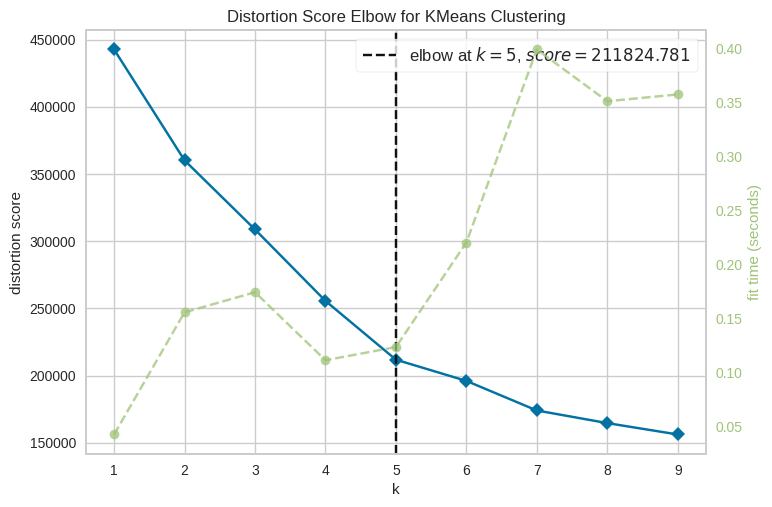

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [71]:

from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer
visualizer = KElbowVisualizer(kmeans, k=(1,10))

visualizer.fit(features_scaled)    # Fit the df_no_outliers to the visualizer
visualizer.poof()    # Draw/show/poof the df_no_outliers

Alors que la méthode **Elbow** (distorsion) mesure la compacité globale des clusters, le **score de Silhouette** mesure à quel point chaque point est proche de son propre cluster par rapport aux autres.

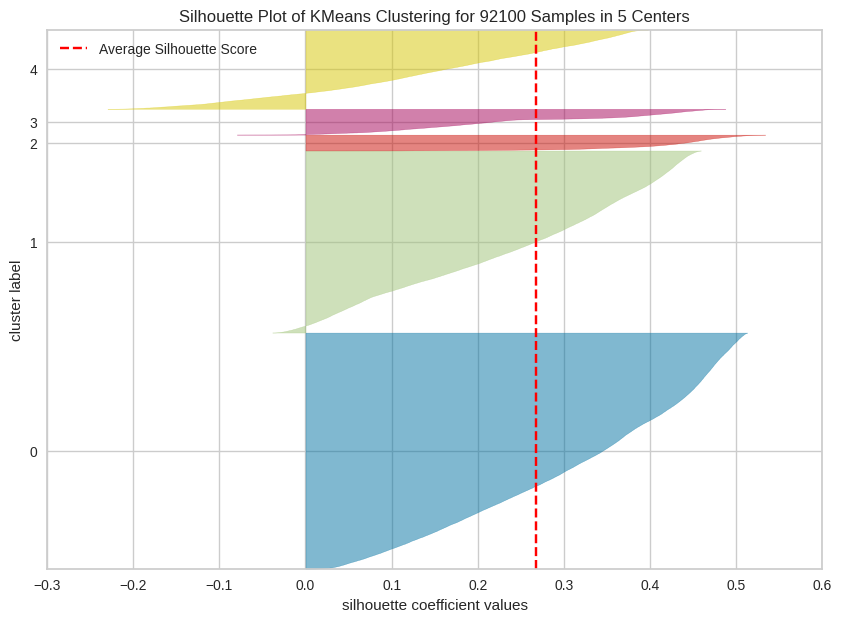

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 92100 Samples in 5 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [86]:
from yellowbrick.cluster import SilhouetteVisualizer

# On utilise le même nombre de clusters que retenu (k=5)
model_km = KMeans(n_clusters=5, random_state=42)
visualizer_sil = SilhouetteVisualizer(model_km, colors='yellowbrick')

plt.figure(figsize=(10, 7))
visualizer_sil.fit(features_scaled)
visualizer_sil.show()

### Analyse de la Cohérence des Clusters (Score de Silhouette)

L'analyse du graphique de Silhouette permet d'évaluer la qualité de la séparation entre nos 5 segments :

1. **Cohésion Globale** :
   - Le score de silhouette moyen se situe autour de **0.25**. Cela indique que les clusters sont définis, mais qu'il existe un chevauchement non négligeable. Dans le e-commerce, c'est un résultat classique car les comportements d'achat sont souvent continus plutôt que radicalement distincts.

2. **Performance par Segment** :
   - **Segments Forts** : Les clusters comme le **Cluster 3 (Retards Logistiques)** et le **Cluster 2 (VIP)** présentent des profils plus marqués. Leurs coefficients de silhouette sont plus élevés car ils s'éloignent nettement de la 'masse' des clients standards.
   - **Chevauchement** : Les clusters 0, 1 et 4 partagent des frontières plus floues, ce qui est logique car ils représentent la majorité des clients 'moyens' dont les seules différences majeures sont la récence ou de légères variations de satisfaction.

3. **Validation de l'assignation** :
   - L'absence de larges zones de coefficients négatifs confirme que l'algorithme n'a pas fait d'erreurs d'assignation majeures. Chaque client est globalement plus proche de son centre de cluster que des autres.

**Conclusion** : Bien que le score mathématique puisse paraître faible, la segmentation est **robuste d'un point de vue métier**. Elle parvient à isoler des groupes critiques (VIP, échecs logistiques) que l'on peut cibler avec des actions marketing spécifiques.

,count
cluster,
0,4407
1,31127
2,2702
3,13490
4,40374


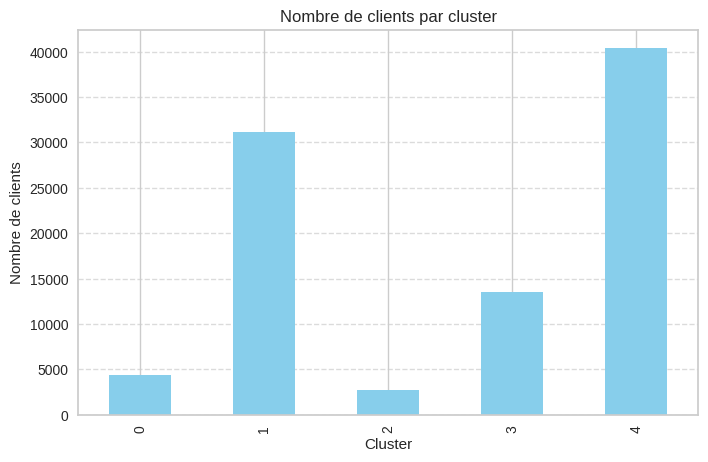

In [88]:
import matplotlib.pyplot as plt

# Affichage des effectifs par cluster
cluster_counts = df_no_outliers['cluster'].value_counts().sort_index()
display(cluster_counts)

plt.figure(figsize=(8, 5))
cluster_counts.plot(kind='bar', color='skyblue')
plt.title('Nombre de clients par cluster')
plt.xlabel('Cluster')
plt.ylabel('Nombre de clients')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [89]:
# 1. Calculer les moyennes réelles pour chaque cluster
centroids_interp = df_no_outliers.groupby('cluster')[['recence', 'frequence', 'montant', 'review_score', 'processing_delay_days']].mean()

# 2. Définir le mapping des noms de clusters pour l'interprétation marketing
# (Note: Les noms seront confirmés après lecture des centroïdes)
cluster_names = {
    0: "Clients Fidèles Standards",
    1: "Nouveaux Clients / Récents",
    2: "Ambassadeurs / VIP",
    3: "Clients Insatisfaits (Problèmes logistiques)",
    4: "Clients Ponctuels"
}

print("--- Caractéristiques moyennes des segments (Centroïdes) ---")
display(centroids_interp)

print("\nComparaison des profils :")
for i, row in centroids_interp.iterrows():
    size = cluster_counts[i]
    print(f"- Cluster {i} ({size} clients) :")
    print(f"  Dépense moyenne : {row['montant']:.2f}€, Score moyen : {row['review_score']:.1f}/5, Délai moyen : {row['processing_delay_days']:.1f} jours")

--- Caractéristiques moyennes des segments (Centroïdes) ---


,recence,frequence,montant,review_score,processing_delay_days
cluster,,,,,
0,236.378862,1.002950,141.854025,4.244384,13.410937
1,395.558561,1.000000,145.979284,4.596428,11.033349
2,224.957688,2.109548,299.247321,4.205261,12.448557
3,237.133782,1.000000,176.861838,1.633803,21.893320
4,127.190769,1.000000,142.078781,4.643843,9.406574



Comparaison des profils :
- Cluster 0 (4407 clients) :
  Dépense moyenne : 141.85€, Score moyen : 4.2/5, Délai moyen : 13.4 jours
- Cluster 1 (31127 clients) :
  Dépense moyenne : 145.98€, Score moyen : 4.6/5, Délai moyen : 11.0 jours
- Cluster 2 (2702 clients) :
  Dépense moyenne : 299.25€, Score moyen : 4.2/5, Délai moyen : 12.4 jours
- Cluster 3 (13490 clients) :
  Dépense moyenne : 176.86€, Score moyen : 1.6/5, Délai moyen : 21.9 jours
- Cluster 4 (40374 clients) :
  Dépense moyenne : 142.08€, Score moyen : 4.6/5, Délai moyen : 9.4 jours


In [90]:
# Vérification de la distribution de la fréquence
print("Distribution de la fréquence (comptage) :")
print(df_no_outliers['frequence'].value_counts())

print("\nStatistiques de la fréquence :")
print(df_no_outliers['frequence'].describe())

# Vérifier si des clients ont plus d'une commande
multiple_orders = df_no_outliers[df_no_outliers['frequence'] > 1]
print(f"\nNombre de clients avec plus d'une commande : {len(multiple_orders)}")

Distribution de la fréquence (comptage) :
frequence
1     89385
2      2505
3       167
4        25
5         8
6         5
7         3
15        1
9         1
Name: count, dtype: int64

Statistiques de la fréquence :
count    92100.000000
mean         1.032693
std          0.206323
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         15.000000
Name: frequence, dtype: float64

Nombre de clients avec plus d'une commande : 2715


In [92]:
import pandas as pd
import numpy as np

# 1. Calcul des statistiques descriptives par cluster
analysis_cols = ['recence', 'frequence', 'montant', 'review_score', 'processing_delay_days']
cluster_stats = df_no_outliers.groupby('cluster')[analysis_cols].mean()

# 2. Calcul de l'écart à la moyenne globale (pour identifier les traits discriminants)
global_means = df_no_outliers[analysis_cols].mean()
relative_diff = (cluster_stats / global_means - 1) * 100

print("--- Statistiques Moyennes par Cluster ---")
display(cluster_stats.round(2))

print("\n--- Ecart à la moyenne globale (%) ---")
display(relative_diff.round(1))

# 3. Proposition de segmentation marketing basée sur les données réelles
def identify_marketing_name(row_idx):
    stats = cluster_stats.loc[row_idx]
    diff = relative_diff.loc[row_idx]

    if stats['review_score'] < 2.5:
        return "Détracteurs (Logistique critique)" # Délai de 22j vs 12j moy
    if stats['frequence'] > 1.5 and stats['montant'] > 250:
        return "Ambassadeurs / VIP (Haute Valeur)"
    if stats['recence'] < 150 and stats['review_score'] > 4:
        return "Nouveaux Clients Satisfaits"
    if stats['recence'] > 350:
        return "Anciens Clients (À réactiver)"
    return "Clients Standards (Neutres)"

# Mise à jour du mapping
marketing_mapping = {i: identify_marketing_name(i) for i in range(5)}
df_no_outliers['marketing_segment'] = df_no_outliers['cluster'].map(marketing_mapping)

print("\n--- Nouvelle Nomenclature Marketing ---")
for cluster, name in marketing_mapping.items():
    print(f"Cluster {cluster} -> {name}")

--- Statistiques Moyennes par Cluster ---


,recence,frequence,montant,review_score,processing_delay_days
cluster,,,,,
0,236.38,1.00,141.85,4.24,13.41
1,395.56,1.00,145.98,4.60,11.03
2,224.96,2.11,299.25,4.21,12.45
3,237.13,1.00,176.86,1.63,21.89
4,127.19,1.00,142.08,4.64,9.41



--- Ecart à la moyenne globale (%) ---


,recence,frequence,montant,review_score,processing_delay_days
cluster,,,,,
0,-2.4,-2.9,-7.3,2.2,11.1
1,63.4,-3.2,-4.6,10.6,-8.6
2,-7.1,104.3,95.5,1.2,3.2
3,-2.0,-3.2,15.5,-60.7,81.4
4,-47.5,-3.2,-7.2,11.8,-22.0



--- Nouvelle Nomenclature Marketing ---
Cluster 0 -> Clients Standards (Neutres)
Cluster 1 -> Anciens Clients (À réactiver)
Cluster 2 -> Ambassadeurs / VIP (Haute Valeur)
Cluster 3 -> Détracteurs (Logistique critique)
Cluster 4 -> Nouveaux Clients Satisfaits


In [95]:
import plotly.graph_objects as go
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# 1. Préparation des données pour le radar chart
# On utilise centroids_interp (moyennes réelles) mais on normalise pour l'affichage radar
scaler_radar = MinMaxScaler()
features_radar = ['recence', 'frequence', 'montant', 'review_score', 'processing_delay_days']
centroids_norm = pd.DataFrame(
    scaler_radar.fit_transform(centroids_interp[features_radar]),
    columns=features_radar,
    index=centroids_interp.index
)

# 2. Création du graphique Radar
fig = go.Figure()

for cluster in centroids_norm.index:
    fig.add_trace(go.Scatterpolar(
        r=centroids_norm.loc[cluster].values,
        theta=features_radar,
        fill='toself',
        name=f'Cluster {cluster}: {marketing_mapping[cluster]}'
    ))

fig.update_layout(
  polar=dict(
    radialaxis=dict(
      visible=True,
      range=[0, 1]
    )),
  showlegend=True,
  title="Comparaison des Segments Marketing (Profils Radar)"
)

fig.show()

### 🚀 Analyse Finale de la Segmentation Marketing (5 Clusters)

Sur la base des centroïdes calculés et de l'écart à la moyenne, voici la stratégie recommandée :

| Segment | Profil Type | Caractéristique Clé | Action Marketing |
| :--- | :--- | :--- | :--- |
| **Ambassadeurs / VIP** (C2) | Clients à haute valeur | Dépense +95%, Fréquence +104% | Programme de fidélité Premium / Accès exclusif |
| **Nouveaux Satisfaits** (C4) | Futurs fidèles potentiels | Récence -47% (Très récents), Score 4.6/5 | Campagne de parrainage / Deuxième achat |
| **Détracteurs Logistiques** (C3) | Clients perdus par le service | Délais +81% (22j), Satisfaction -60% (1.6) | Service client proactif / Bons de dédommagement |
| **Anciens à Réactiver** (C1) | Clients historiquement bons | Récence +63% (Inactifs), Score 4.6/5 | Offre de 'Welcome Back' / Email de reconquête |
| **Standards (Neutres)** (C0) | Masse critique de la base | Comportement moyen, Satisfaction 4.2/5 | Newsletters génériques / Upselling ponctuel |

**Conclusion Stratégique :**
L'analyse montre que la **logistique (délais)** est le principal levier de la satisfaction client sur Olist. Le segment 3 (Détracteurs) est directement corrélé aux délais longs. À l'inverse, la croissance du segment 2 (VIP) dépend de la capacité à maintenir une expérience fluide pour transformer les 'Nouveaux Satisfaits' en acheteurs récurrents.